Câu 1:
- Viết chương trình sử dụng mean filter cho ảnh (0.5 Điểm)

[[ 99 101 103 ...  87  89  90]
 [ 99 101 103 ...  85  87  88]
 [ 99 101 103 ...  82  83  84]
 ...
 [ 40  42  41 ...  60  62  64]
 [ 40  42  41 ...  61  64  65]
 [ 41  43  41 ...  62  64  66]]


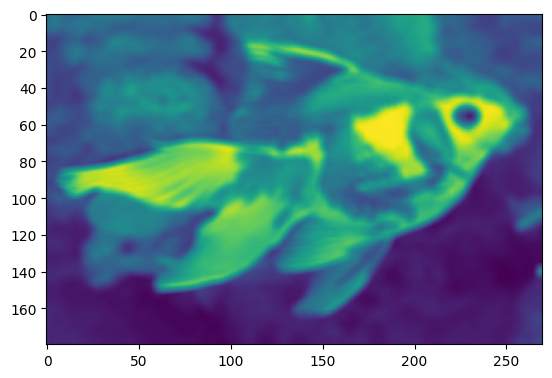

In [5]:
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as sn
import matplotlib.pyplot as plt
import colorsys

a = iio.imread('images/a.jpg', mode = 'F')
k = np.ones((5,5))/25
b = sn.convolve(a, k).astype(np. uint8)
iio.imsave('images/a_mean_filtered.jpg', b)
print(b)
plt.imshow(b )
plt.show()


- Viết chương trình sử dụng filter xác định biên của hình ảnh trên(0.5 Điểm)

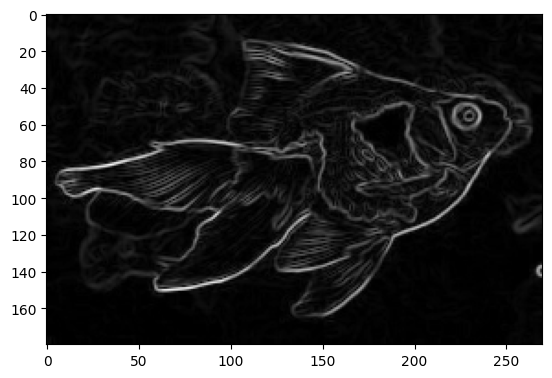

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import scipy.ndimage as sn
from skimage import filters
import colorsys

a = iio.imread('images/a.jpg', mode = 'F')
b = filters.sobel(a).astype(np.uint8)
iio.imsave('images/a_sobel_filtered.jpg', b)
plt.imshow(b, cmap='gray')
plt.show()

- Viết chương trình đổi màu ảnh từ không gian màu BGR sang một màu ngẫu nhiên (RGB) bằng cách thay đổi các kênh màu một cách ngẫu nhiên, sau đó lưu hình mới vào file a_random_color.jpg(0.5 Điểm)

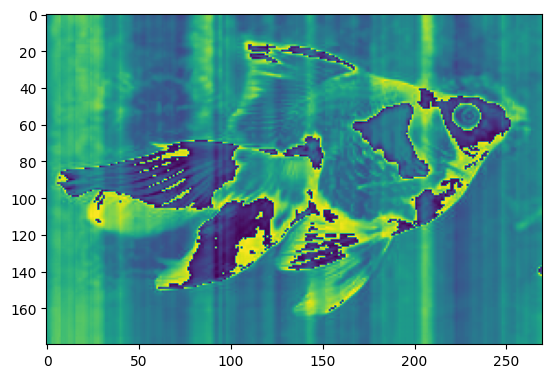

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio

data = iio.imread('images/a.jpg')
bdata = (data[0,:,2] + data[1,:,0] + data[:,:,2])
plt.imshow(bdata)
plt.show()

- Chuyển ảnh sang không gian màu HSV và tách riêng kênh Hue, Saturation, Value
để lưu thành ba ảnh grayscale tương ứng (a_hue.jpg, a_saturation.jpg,
a_value.jpg) (0.5 Điểm)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


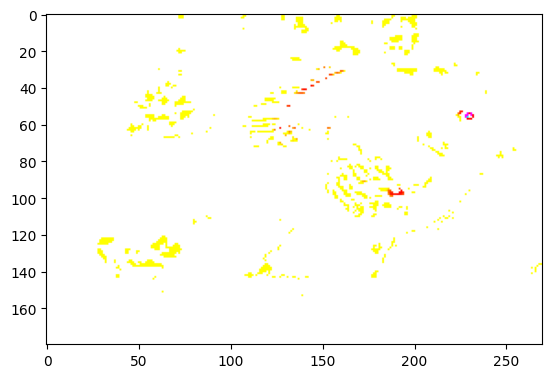

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as iio
import colorsys

rgb = iio.imread('images/a.jpg')
rgb2hsv = np.vectorize(colorsys.rgb_to_hsv)
h,s,v = rgb2hsv(rgb[:,:,0], rgb[:,:,1], rgb[:,:,2])
h *= h
hsv2rgb = np.vectorize(colorsys.hsv_to_rgb)
rgb2 = hsv2rgb(h, s, v)
rgb2 = np.array(rgb2).transpose((1, 2, 0))
plt.imshow(rgb2)
plt.show()

Câu 2 (4 Điểm): Viết một chương trình Python sử dụng OpenCV để tạo menu động cho
phép người dùng chọn các phương pháp biến đổi ảnh từ một danh sách mở rộng, áp
dụng cho nhiều ảnh cùng lúc, và thực hiện các phân tích bổ sung. Các yêu cầu cụ thể:
1. Tạo một menu động cho phép người dùng chọn các phương pháp biến đổi ảnh sau:
- Image inverse transformation(0.5 Điểm)
- Gamma-Correction (với giá trị gamma ngẫu nhiên từ 0.5 đến 2.0) (0.5 Điểm)
- Log Transformation (với hệ số nhân ngẫu nhiên từ 1.0 đến 5.0) (0.5 Điểm)
- Histogram equalization(0.5 Điểm)
- Contrast Stretching (tùy chỉnh với giá trị min và max ngẫu nhiên từ 0 đến 255)
(0.5 Điểm)
- Adaptive Histogram Equalization (sử dụng CLAHE với ô lưới 8x8) (0.5 Điểm)
2. Chương trình phải xử lý đồng thời ba ảnh đầu vào có tên image1.jpg, image2.jpg, và
image3.jpg (0.5 Điểm)
3. Khi người dùng nhấn các phím sau, chương trình sẽ thực hiện biến đổi tương ứng
trên cả ba ảnh (0.5 Điểm)
- Phím I: Image inverse transformation
- Phím G: Gamma-Correction
- Phím L: Log Transformation
- Phím H: Histogram equalization
- Phím C: Contrast Stretching
- Phím A: Adaptive Histogram Equalization4. Đối với mỗi biến đổi, lưu kết quả của từng ảnh vào các file riêng biệt với tên định
dạng output_[phương pháp]_[số ảnh].jpg (ví dụ: output_inverse_1.jpg,
output_gamma_2.jpg).

=== MENU BIẾN ĐỔI ẢNH ===
Nhấn phím để chọn biến đổi:
I - Image inverse
G - Gamma correction
L - Log transform
H - Histogram equalization
C - Contrast stretching
A - Adaptive histogram equalization (CLAHE)
Q - Thoát


Log hệ số ảnh 1: 2.76
Đã lưu: images/output_log_1.jpg


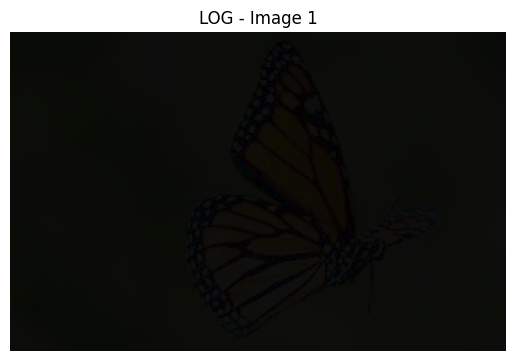

Log hệ số ảnh 2: 4.02
Đã lưu: images/output_log_2.jpg


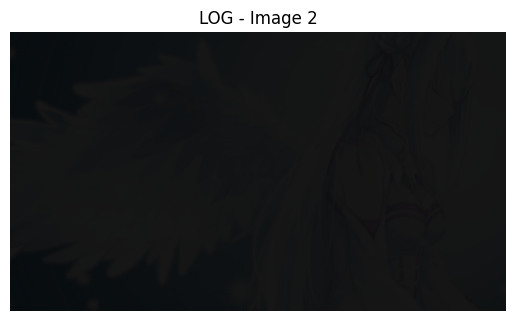

Log hệ số ảnh 3: 3.79
Đã lưu: images/output_log_3.jpg


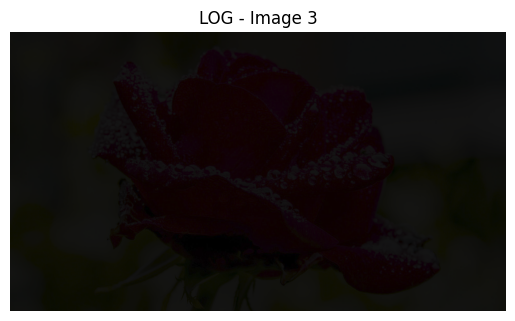

Đã lưu: images/output_hist_1.jpg


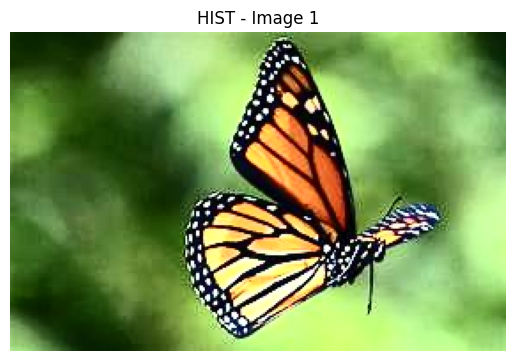

Đã lưu: images/output_hist_2.jpg


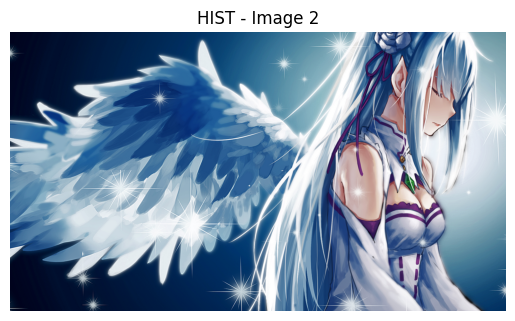

Đã lưu: images/output_hist_3.jpg


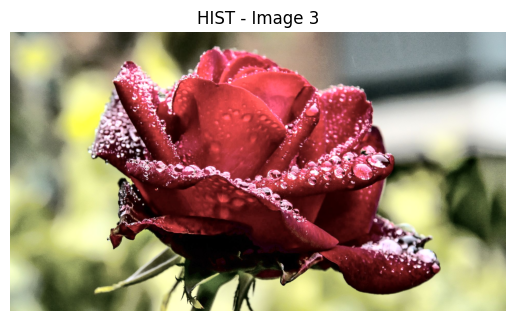

Kết thúc chương trình.


In [ ]:
import cv2
import numpy as np
import random
import os
import matplotlib.pyplot as plt

def inverse_image(img):
    return 255 - img

def gamma_correction(img, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([(i / 255.0) ** inv_gamma * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img, table)

def log_transform(img, c):
    img_float = img.astype(np.float32)
    result = c * np.log1p(img_float)
    result = np.clip(result, 0, 255)
    return result.astype(np.uint8)

def histogram_equalization(img):
    if len(img.shape) == 2:
        return cv2.equalizeHist(img)
    else:
        ycrcb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
        ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])
        return cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2BGR)

def contrast_stretching(img):
    min_val = random.randint(0, 100)
    max_val = random.randint(150, 255)
    img_float = img.astype(np.float32)
    stretched = (img_float - min_val) * (255.0 / (max_val - min_val))
    stretched = np.clip(stretched, 0, 255)
    return stretched.astype(np.uint8)

def adaptive_hist_equalization(img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if len(img.shape) == 2:
        return clahe.apply(img)
    else:
        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        lab[:, :, 0] = clahe.apply(lab[:, :, 0])
        return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def apply_transformation(images, method_key):
    for i, path in enumerate(images):
        img = cv2.imread(path)
        if img is None:
            print(f"Không thể đọc ảnh: {path}")
            continue
        if method_key == 'I':
            result = inverse_image(img)
            method_name = "inverse"
        elif method_key == 'G':
            gamma = round(random.uniform(0.5, 2.0), 2)
            result = gamma_correction(img, gamma)
            method_name = "gamma"
            print(f"Gamma ảnh {i+1}: {gamma}")
        elif method_key == 'L':
            c = round(random.uniform(1.0, 5.0), 2)
            result = log_transform(img, c)
            method_name = "log"
            print(f"Log hệ số ảnh {i+1}: {c}")
        elif method_key == 'H':
            result = histogram_equalization(img)
            method_name = "hist"
        elif method_key == 'C':
            result = contrast_stretching(img)
            method_name = "contrast"
        elif method_key == 'A':
            result = adaptive_hist_equalization(img)
            method_name = "adaptive"
        else:
            print("Phím không hợp lệ.")
            return
        output_name = f"images/output_{method_name}_{i+1}.jpg"
        cv2.imwrite(output_name, result)
        print(f"Đã lưu: {output_name}")

        title = f"{method_name.upper()} - Image {i+1}"
        show_image(title, result)

def show_image(title, img):
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()
images = ['images/image1.jpg', 'images/image2.jpg', 'images/image3.jpg']
print("=== MENU BIẾN ĐỔI ẢNH ===")
print("Nhấn phím để chọn biến đổi:")
print("I - Image inverse")
print("G - Gamma correction")
print("L - Log transform")
print("H - Histogram equalization")
print("C - Contrast stretching")
print("A - Adaptive histogram equalization (CLAHE)")
print("Q - Thoát")

while True:
    key = input("\n>> Nhấn phím (I/G/L/H/C/A hoặc Q để thoát): ").upper()
    if key == 'Q':
        print("Kết thúc chương trình.")
        break
    elif key in ['I', 'G', 'L', 'H', 'C', 'A']:
        apply_transformation(images, key)
    else:
        print("Phím không hợp lệ. Vui lòng chọn lại.")


Câu 3 (4 Điểm): Viết một chương trình Python sử dụng OpenCV để xử lý ba ảnh:
colorful-ripe-tropical-fruits.jpg, quang-ninh.jpg, và pagoda.jpg với các phương pháp
biến đổi và tiền xử lý nâng cao.
- Tăng kích thước ảnh colorful-ripe-tropical-fruits.jpg thêm 30 pixel ở cả chiều
rộng và chiều cao. (0.5 Điểm)
- Xoay ảnh quang-ninh.jpg 45 độ theo chiều kim đồng hồ và lật ngang. (0.5 Điểm)
- Tăng kích thước ảnh pagoda.jpg lên 5 lần và áp dụng Gaussian blur với kernel
7x7 để làm mịn. (0.5 Điểm)
- Ứng dụng công thức bên dưới cho ảnh pagoda.jpg (1.5 Điểm)

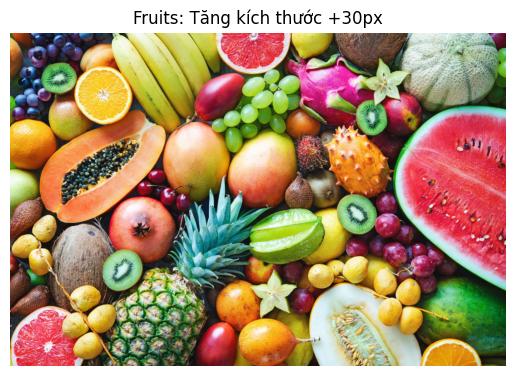

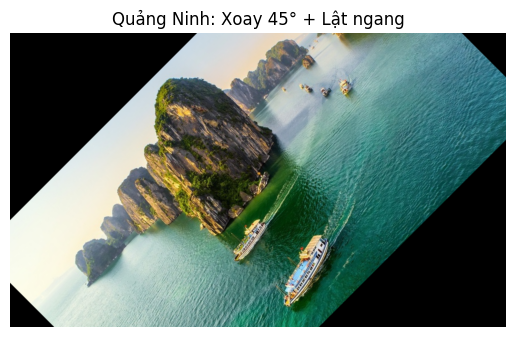

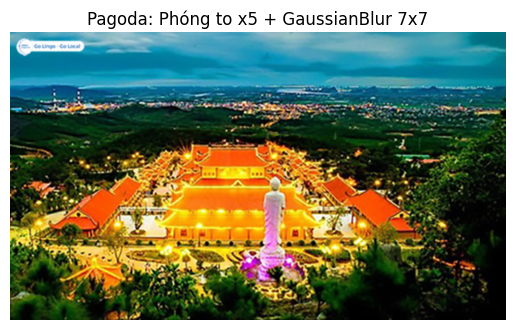

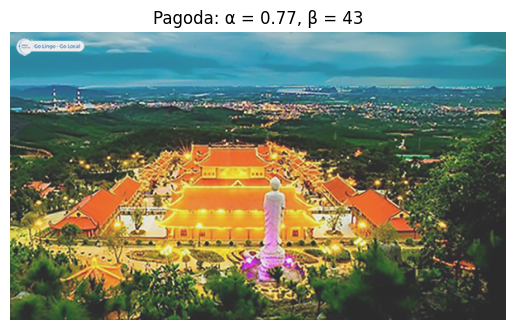

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def adjust_brightness_contrast(image, alpha, beta):
    result = np.clip(alpha * image + beta, 0, 255).astype(np.uint8)
    return result

def show_image(img, title):
    if len(img.shape) == 3:
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = img
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis('off')
    plt.show() 

img1 = cv2.imread('images/colorful-ripe-tropical-fruits.jpg')
if img1 is None:
    raise Exception("Không tìm thấy ảnh colorful-ripe-tropical-fruits.jpg")
h1, w1 = img1.shape[:2]
resized_img1 = cv2.resize(img1, (w1 + 30, h1 + 30))
cv2.imwrite('images/output_fruits_resized.jpg', resized_img1)
show_image(resized_img1, "Fruits: Tăng kích thước +30px")

img2 = cv2.imread('images/quang_ninh.jpg')
if img2 is None:
    raise Exception("Không tìm thấy ảnh quang_ninh.jpg")
(h2, w2) = img2.shape[:2]
center = (w2 // 2, h2 // 2)
M = cv2.getRotationMatrix2D(center, -45, 1.0)
rotated_img2 = cv2.warpAffine(img2, M, (w2, h2))
flipped_img2 = cv2.flip(rotated_img2, 1)
cv2.imwrite('images/output_quangninh_rotated_flipped.jpg', flipped_img2)
show_image(flipped_img2, "Quảng Ninh: Xoay 45° + Lật ngang")

img3 = cv2.imread('images/pagoda.jpg')
if img3 is None:
    raise Exception("Không tìm thấy ảnh pagoda.jpg")
resized_img3 = cv2.resize(img3, (img3.shape[1]*5, img3.shape[0]*5))
blurred_img3 = cv2.GaussianBlur(resized_img3, (7, 7), 0)
cv2.imwrite('images/output_pagoda_blurred.jpg', blurred_img3)
show_image(blurred_img3, "Pagoda: Phóng to x5 + GaussianBlur 7x7")

alpha = np.random.uniform(0.5, 2.0)
beta = np.random.randint(-50, 51)
contrast_img = adjust_brightness_contrast(img3, alpha, beta)
cv2.imwrite('images/output_pagoda_contrast_brightness.jpg', contrast_img)
show_image(contrast_img, f"Pagoda: α = {alpha:.2f}, β = {beta}")

